In [136]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns

In [137]:
df = pd.read_csv('eye-tracking-events-data.csv')

In [138]:
df

,Unnamed: 0.1,Unnamed: 0,recording id,timestamp [ns],name,type,wearer_name,has_corruption,door_sequence,matter_duration,...,p1_duration,p2_duration,p3_duration,p4_duration,p5_duration,p6_duration,p7_duration,phone_pickups,phone_duration,overall_duration
0,0,0,b5cff087-0b53-499e-997d-05af39002d55,1695733480308000000,recording.begin,recording,D01-P010,False,"d1.in,d2.out,d3.in,d4.out,d5.in,d6.out",0 days 00:01:57.866622,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:20:09.907000
1,1,1,b5cff087-0b53-499e-997d-05af39002d55,1695733580411684000,exterior21.begin,cloud,D01-P010,False,"d1.in,d2.out,d3.in,d4.out,d5.in,d6.out",0 days 00:01:57.866622,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:20:09.907000
2,2,2,b5cff087-0b53-499e-997d-05af39002d55,1695733640648304000,exterior21.end,cloud,D01-P010,False,"d1.in,d2.out,d3.in,d4.out,d5.in,d6.out",0 days 00:01:57.866622,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:20:09.907000
3,3,3,b5cff087-0b53-499e-997d-05af39002d55,1695733664728872000,matter1.begin,cloud,D01-P010,False,"d1.in,d2.out,d3.in,d4.out,d5.in,d6.out",0 days 00:01:57.866622,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:20:09.907000
4,4,4,b5cff087-0b53-499e-997d-05af39002d55,1695733664728872000,d1.in,cloud,D01-P010,False,"d1.in,d2.out,d3.in,d4.out,d5.in,d6.out",0 days 00:01:57.866622,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0 days 00:20:09.907000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4237,4237,4237,adb20035-13c3-41f1-b08d-07c0f338a2a6,1696192433681506000,d6.out,cloud,D01-P064,False,"d1.in,d2.out,d3.in,d4.out,d6.in,d6.out",0 days 00:01:08.544715,...,0 days 00:02:01.244742,0 days 00:00:32.971770,NaN,NaN,NaN,NaN,0 days 00:00:35.825918,4.0,0 days 00:01:54.531953,0 days 00:18:21.111000
4238,4238,4238,adb20035-13c3-41f1-b08d-07c0f338a2a6,1696192435749759000,thought1.end,cloud,D01-P064,False,"d1.in,d2.out,d3.in,d4.out,d6.in,d6.out",0 days 00:01:08.544715,...,0 days 00:02:01.244742,0 days 00:00:32.971770,NaN,NaN,NaN,NaN,0 days 00:00:35.825918,4.0,0 days 00:01:54.531953,0 days 00:18:21.111000
4239,4239,4239,adb20035-13c3-41f1-b08d-07c0f338a2a6,1696192436945640000,p71.begin,cloud,D01-P064,False,"d1.in,d2.out,d3.in,d4.out,d6.in,d6.out",0 days 00:01:08.544715,...,0 days 00:02:01.244742,0 days 00:00:32.971770,NaN,NaN,NaN,NaN,0 days 00:00:35.825918,4.0,0 days 00:01:54.531953,0 days 00:18:21.111000
4240,4240,4240,adb20035-13c3-41f1-b08d-07c0f338a2a6,1696192472771558000,p71.end,cloud,D01-P064,False,"d1.in,d2.out,d3.in,d4.out,d6.in,d6.out",0 days 00:01:08.544715,...,0 days 00:02:01.244742,0 days 00:00:32.971770,NaN,NaN,NaN,NaN,0 days 00:00:35.825918,4.0,0 days 00:01:54.531953,0 days 00:18:21.111000


In [139]:
columns_to_drop = ['Unnamed: 0.1', 'Unnamed: 0', 'timestamp [ns]','name', 'type' ]
df = df.drop(columns=columns_to_drop)

In [140]:
df.drop_duplicates(subset=['wearer_name'], keep='first', inplace=True)
df.reset_index(drop=True, inplace=True)

In [141]:
columns_to_fill = ['matter_duration', 'life_duration', 'thought_duration', 'p1_duration', 'p2_duration', 'p3_duration', 'p4_duration', 'p5_duration', 'p6_duration', 'p7_duration', 'phone_pickups', 'phone_duration']
df.loc[:, columns_to_fill] = df[columns_to_fill].fillna(0)

In [142]:
df.to_csv('eye-tracking-events-reduced.csv')
df

,recording id,wearer_name,has_corruption,door_sequence,matter_duration,life_duration,thought_duration,p1_duration,p2_duration,p3_duration,p4_duration,p5_duration,p6_duration,p7_duration,phone_pickups,phone_duration,overall_duration
0,b5cff087-0b53-499e-997d-05af39002d55,D01-P010,False,"d1.in,d2.out,d3.in,d4.out,d5.in,d6.out",0 days 00:01:57.866622,0 days 00:01:14.397229,0 days 00:12:32.545630,0,0,0,0,0,0,0,0.0,0,0 days 00:20:09.907000
1,0ca2b022-aee7-4299-a2a1-f70663e48628,D03-P011,False,"d1.in,d2.out,d3.in,d4.out,d6.in,d6.out",0 days 00:01:38.328851,0 days 00:03:02.418749,0 days 00:07:42.681755,0,0,0,0 days 00:01:31.444565,0 days 00:00:49.010874,0,0,5.0,0 days 00:02:26.922757,0 days 00:17:18.830000
2,5459d7cb-ad76-41b5-8547-78d0993ce78b,D03-P012,False,"d1.in,d2.out,d3.in,d4.out,d5.in,d6.out",0 days 00:02:43.612596,0 days 00:06:34.444864,0 days 00:02:12.322145,0,0,0,0,0,0,0,8.0,0 days 00:01:32.974840,0 days 00:16:00.290000
3,d954354a-0daf-434e-b34d-fba86285e06d,D01-P011,False,"d1.in,d2.out,d3.in,d3.out,d3.in,d4.out,d6.in,d...",0 days 00:01:21.307438,0 days 00:01:30.655332,0 days 00:06:32.781681,0 days 00:04:16.418408,0 days 00:01:10.842014,0,0 days 00:00:08.413742,0,0,0,5.0,0 days 00:01:35.651010,0 days 00:19:53.243000
4,b726709d-b664-48c0-8161-0b5b8533d84b,D05-P013,False,"d1.in,d2.out,d3.in,d4.out,d6.in,d5.out",0 days 00:01:24.796128,0 days 00:05:28.292208,0 days 00:05:12.211928,0 days 00:00:36.183004,0,0,0 days 00:00:55.226232,0,0,0,0.0,0,0 days 00:17:04.780000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,40548af0-64d4-4e4c-baa8-f0f8c76ac823,D03-P066,False,"d1.in,d2.out,d3.in,d4.out,d5.in,d6.out",0 days 00:00:45.125706,0 days 00:02:36.094654,0 days 00:10:00.068901,0,0,0,0,0,0,0,7.0,0 days 00:01:16.566664,0 days 00:14:49.640000
182,a338fabd-600c-4be0-88a4-a00b19e3b487,D01-P063,False,"d1.in,d2.out,d3.in,d4.out,d5.in,d6.out",0 days 00:02:34.221634,0 days 00:06:29.211382,0 days 00:05:54.007669,0,0 days 00:01:27.880332,0,0,0,0,0 days 00:00:36.403802,5.0,0 days 00:00:39.228483,0 days 00:21:48.761000
183,8de10704-68d9-4bdd-957c-42a60fdbf562,D05-P050,False,"d1.in,d2.out,d3.in,d4.out,d5.in,d6.out",0 days 00:01:39.680266,0 days 00:04:44.624897,0 days 00:19:22.228321,0,0,0 days 00:00:43.987281,0,0,0,0,1.0,0 days 00:00:19.674168,0 days 00:28:17.680000
184,6c8a0694-0c8f-4ae3-978e-e3657f3f4fd1,D02-P058,False,"d1.in,d2.out,d3.in,d4.out,d6.in,d6.out",0 days 00:01:32.709210,0 days 00:05:25.574839,0 days 00:08:34.656428,0,0,0 days 00:00:22.348659,0 days 00:05:13.520172,0,0,0 days 00:00:06.801104,0.0,0,0 days 00:23:08.901000


In [143]:
filtered_df = df[df['has_corruption'] == False]
filtered_df

,recording id,wearer_name,has_corruption,door_sequence,matter_duration,life_duration,thought_duration,p1_duration,p2_duration,p3_duration,p4_duration,p5_duration,p6_duration,p7_duration,phone_pickups,phone_duration,overall_duration
0,b5cff087-0b53-499e-997d-05af39002d55,D01-P010,False,"d1.in,d2.out,d3.in,d4.out,d5.in,d6.out",0 days 00:01:57.866622,0 days 00:01:14.397229,0 days 00:12:32.545630,0,0,0,0,0,0,0,0.0,0,0 days 00:20:09.907000
1,0ca2b022-aee7-4299-a2a1-f70663e48628,D03-P011,False,"d1.in,d2.out,d3.in,d4.out,d6.in,d6.out",0 days 00:01:38.328851,0 days 00:03:02.418749,0 days 00:07:42.681755,0,0,0,0 days 00:01:31.444565,0 days 00:00:49.010874,0,0,5.0,0 days 00:02:26.922757,0 days 00:17:18.830000
2,5459d7cb-ad76-41b5-8547-78d0993ce78b,D03-P012,False,"d1.in,d2.out,d3.in,d4.out,d5.in,d6.out",0 days 00:02:43.612596,0 days 00:06:34.444864,0 days 00:02:12.322145,0,0,0,0,0,0,0,8.0,0 days 00:01:32.974840,0 days 00:16:00.290000
3,d954354a-0daf-434e-b34d-fba86285e06d,D01-P011,False,"d1.in,d2.out,d3.in,d3.out,d3.in,d4.out,d6.in,d...",0 days 00:01:21.307438,0 days 00:01:30.655332,0 days 00:06:32.781681,0 days 00:04:16.418408,0 days 00:01:10.842014,0,0 days 00:00:08.413742,0,0,0,5.0,0 days 00:01:35.651010,0 days 00:19:53.243000
4,b726709d-b664-48c0-8161-0b5b8533d84b,D05-P013,False,"d1.in,d2.out,d3.in,d4.out,d6.in,d5.out",0 days 00:01:24.796128,0 days 00:05:28.292208,0 days 00:05:12.211928,0 days 00:00:36.183004,0,0,0 days 00:00:55.226232,0,0,0,0.0,0,0 days 00:17:04.780000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,40548af0-64d4-4e4c-baa8-f0f8c76ac823,D03-P066,False,"d1.in,d2.out,d3.in,d4.out,d5.in,d6.out",0 days 00:00:45.125706,0 days 00:02:36.094654,0 days 00:10:00.068901,0,0,0,0,0,0,0,7.0,0 days 00:01:16.566664,0 days 00:14:49.640000
182,a338fabd-600c-4be0-88a4-a00b19e3b487,D01-P063,False,"d1.in,d2.out,d3.in,d4.out,d5.in,d6.out",0 days 00:02:34.221634,0 days 00:06:29.211382,0 days 00:05:54.007669,0,0 days 00:01:27.880332,0,0,0,0,0 days 00:00:36.403802,5.0,0 days 00:00:39.228483,0 days 00:21:48.761000
183,8de10704-68d9-4bdd-957c-42a60fdbf562,D05-P050,False,"d1.in,d2.out,d3.in,d4.out,d5.in,d6.out",0 days 00:01:39.680266,0 days 00:04:44.624897,0 days 00:19:22.228321,0,0,0 days 00:00:43.987281,0,0,0,0,1.0,0 days 00:00:19.674168,0 days 00:28:17.680000
184,6c8a0694-0c8f-4ae3-978e-e3657f3f4fd1,D02-P058,False,"d1.in,d2.out,d3.in,d4.out,d6.in,d6.out",0 days 00:01:32.709210,0 days 00:05:25.574839,0 days 00:08:34.656428,0,0,0 days 00:00:22.348659,0 days 00:05:13.520172,0,0,0 days 00:00:06.801104,0.0,0,0 days 00:23:08.901000


Door sequence

In [144]:
# snakey plot representing the flow of traffic through doors

df_copy = filtered_df.copy()

df_copy = df_copy.dropna(subset=['door_sequence'])

original_doors = sorted(set([door for seq in df_copy['door_sequence'] for door in seq.split(',')]))

desired_doors = ['cube1_entrance', 'cube1_entrance', 'cube1_exit', 'cube1_exit', 'cube2_entrance', 'cube2_entrance', 'cube2_exit', 'cube3_entrance', 'cube3_entrance', 'cube3_exit', 'cube3_exit']

flow_matrix = pd.DataFrame(0, index=original_doors, columns=original_doors)

for sequence in df_copy['door_sequence']:
    doors_visited = sequence.split(',')
    for i in range(len(doors_visited) - 1):
        flow_matrix.loc[doors_visited[i], doors_visited[i + 1]] += 1

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color='black', width=0.5),
        label=original_doors
    ),
    link=dict(
        arrowlen=15,
        source=[original_doors.index(src) for src in flow_matrix.index for _ in range(len(flow_matrix.columns))],
        target=[original_doors.index(dest) for _ in range(len(flow_matrix.index)) for dest in flow_matrix.columns],
        value=flow_matrix.values.flatten()
    )
)])

fig.update_traces(
    node=dict(label=desired_doors),
    selector=dict(type='sankey')
)

# fig.write_html("sankey_plot.html")
# plt.savefig(f"sankey_plot.png")

fig.show()


In [145]:
df

,recording id,wearer_name,has_corruption,door_sequence,matter_duration,life_duration,thought_duration,p1_duration,p2_duration,p3_duration,p4_duration,p5_duration,p6_duration,p7_duration,phone_pickups,phone_duration,overall_duration
0,b5cff087-0b53-499e-997d-05af39002d55,D01-P010,False,"d1.in,d2.out,d3.in,d4.out,d5.in,d6.out",0 days 00:01:57.866622,0 days 00:01:14.397229,0 days 00:12:32.545630,0,0,0,0,0,0,0,0.0,0,0 days 00:20:09.907000
1,0ca2b022-aee7-4299-a2a1-f70663e48628,D03-P011,False,"d1.in,d2.out,d3.in,d4.out,d6.in,d6.out",0 days 00:01:38.328851,0 days 00:03:02.418749,0 days 00:07:42.681755,0,0,0,0 days 00:01:31.444565,0 days 00:00:49.010874,0,0,5.0,0 days 00:02:26.922757,0 days 00:17:18.830000
2,5459d7cb-ad76-41b5-8547-78d0993ce78b,D03-P012,False,"d1.in,d2.out,d3.in,d4.out,d5.in,d6.out",0 days 00:02:43.612596,0 days 00:06:34.444864,0 days 00:02:12.322145,0,0,0,0,0,0,0,8.0,0 days 00:01:32.974840,0 days 00:16:00.290000
3,d954354a-0daf-434e-b34d-fba86285e06d,D01-P011,False,"d1.in,d2.out,d3.in,d3.out,d3.in,d4.out,d6.in,d...",0 days 00:01:21.307438,0 days 00:01:30.655332,0 days 00:06:32.781681,0 days 00:04:16.418408,0 days 00:01:10.842014,0,0 days 00:00:08.413742,0,0,0,5.0,0 days 00:01:35.651010,0 days 00:19:53.243000
4,b726709d-b664-48c0-8161-0b5b8533d84b,D05-P013,False,"d1.in,d2.out,d3.in,d4.out,d6.in,d5.out",0 days 00:01:24.796128,0 days 00:05:28.292208,0 days 00:05:12.211928,0 days 00:00:36.183004,0,0,0 days 00:00:55.226232,0,0,0,0.0,0,0 days 00:17:04.780000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181,40548af0-64d4-4e4c-baa8-f0f8c76ac823,D03-P066,False,"d1.in,d2.out,d3.in,d4.out,d5.in,d6.out",0 days 00:00:45.125706,0 days 00:02:36.094654,0 days 00:10:00.068901,0,0,0,0,0,0,0,7.0,0 days 00:01:16.566664,0 days 00:14:49.640000
182,a338fabd-600c-4be0-88a4-a00b19e3b487,D01-P063,False,"d1.in,d2.out,d3.in,d4.out,d5.in,d6.out",0 days 00:02:34.221634,0 days 00:06:29.211382,0 days 00:05:54.007669,0,0 days 00:01:27.880332,0,0,0,0,0 days 00:00:36.403802,5.0,0 days 00:00:39.228483,0 days 00:21:48.761000
183,8de10704-68d9-4bdd-957c-42a60fdbf562,D05-P050,False,"d1.in,d2.out,d3.in,d4.out,d5.in,d6.out",0 days 00:01:39.680266,0 days 00:04:44.624897,0 days 00:19:22.228321,0,0,0 days 00:00:43.987281,0,0,0,0,1.0,0 days 00:00:19.674168,0 days 00:28:17.680000
184,6c8a0694-0c8f-4ae3-978e-e3657f3f4fd1,D02-P058,False,"d1.in,d2.out,d3.in,d4.out,d6.in,d6.out",0 days 00:01:32.709210,0 days 00:05:25.574839,0 days 00:08:34.656428,0,0,0 days 00:00:22.348659,0 days 00:05:13.520172,0,0,0 days 00:00:06.801104,0.0,0,0 days 00:23:08.901000


In [146]:
timedelta_columns = ['matter_duration', 'life_duration', 'thought_duration', 'p1_duration', 'p2_duration', 'p3_duration', 'p4_duration', 'p5_duration', 'p6_duration', 'p7_duration', 'phone_duration']

df[timedelta_columns] = df[timedelta_columns].apply(lambda x: pd.to_timedelta(x, errors='coerce'))


# df

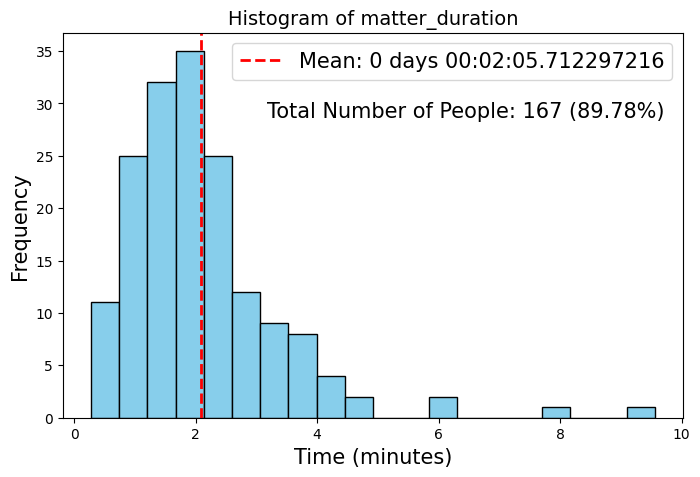

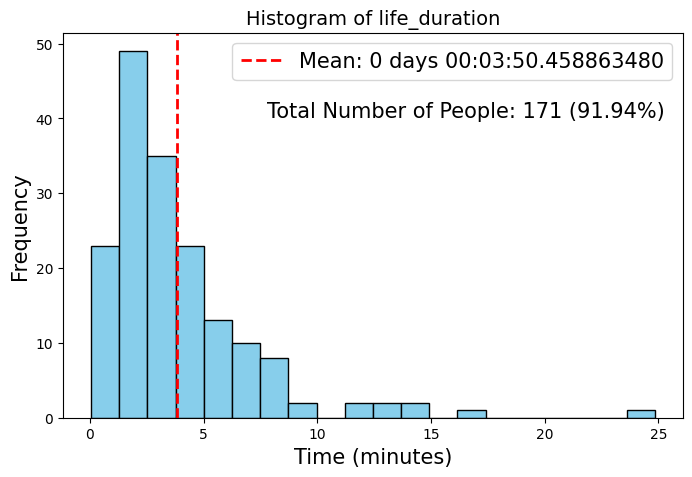

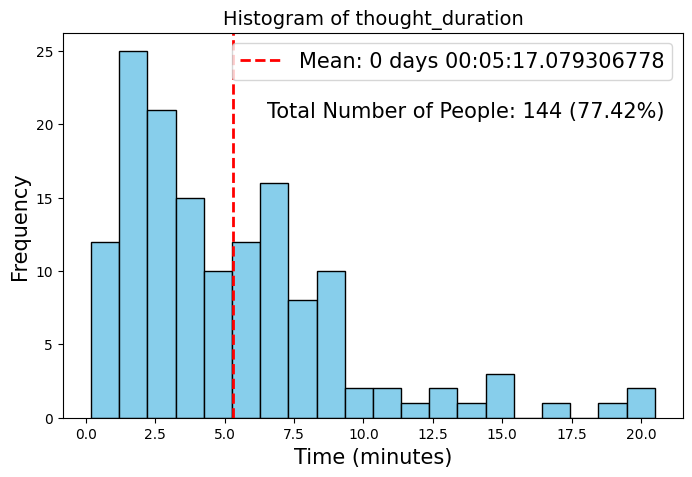

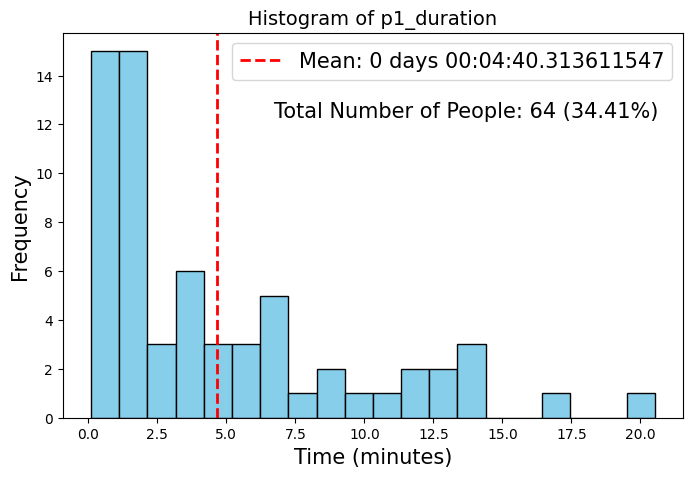

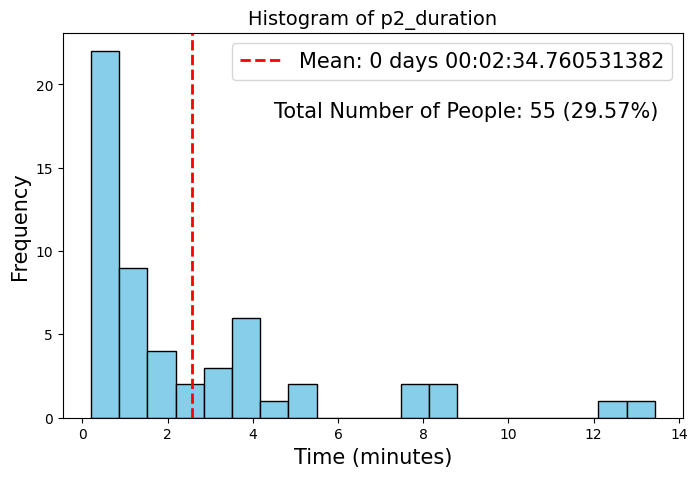

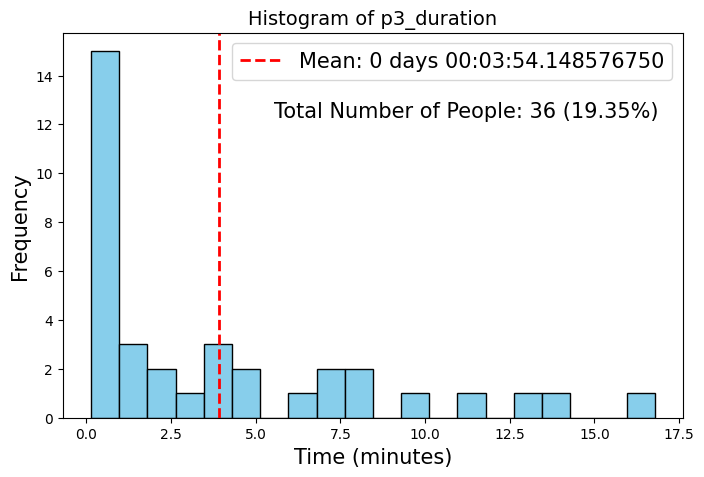

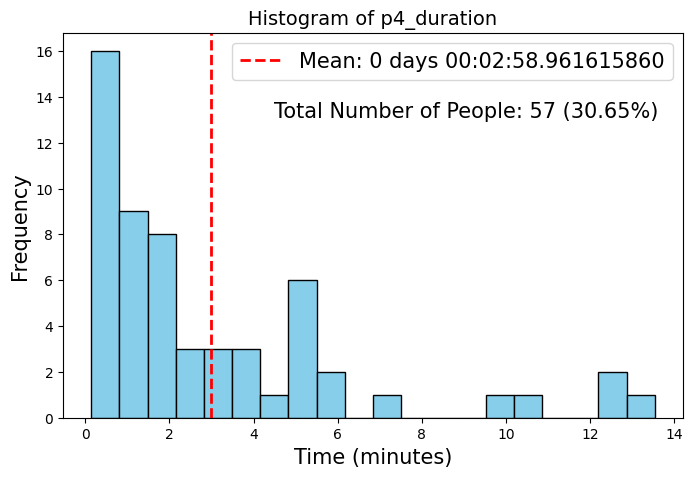

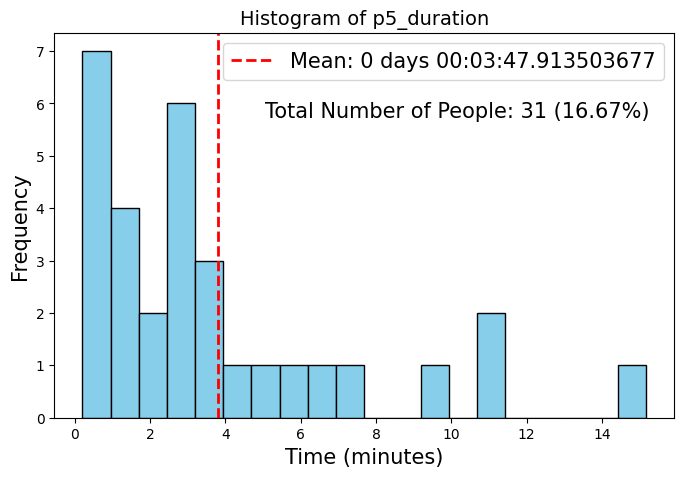

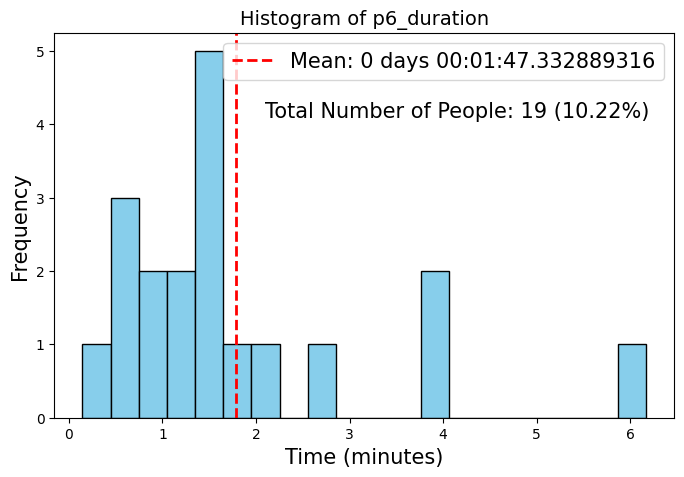

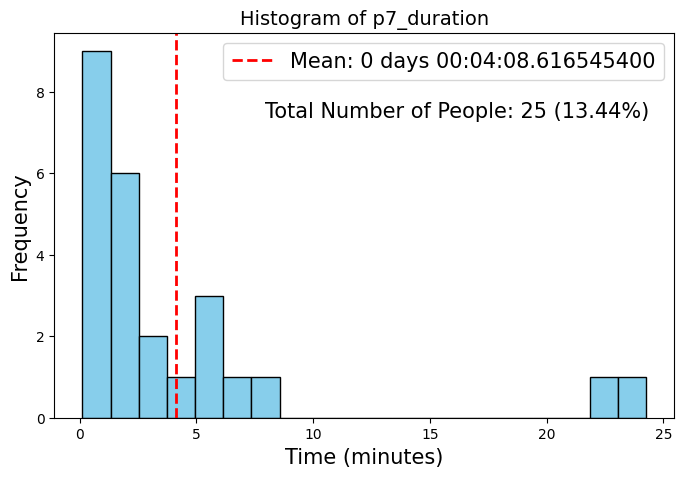

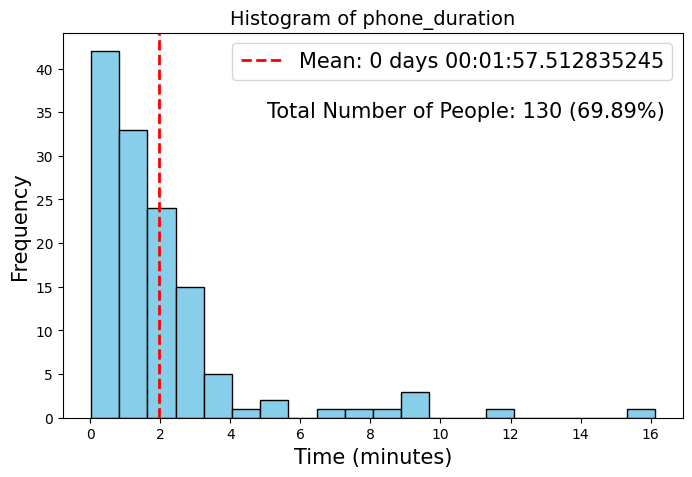

In [147]:
for column in timedelta_columns:
    non_zero_df = df[df[column] != pd.Timedelta(0)]
    
    minutes = non_zero_df[column].dt.total_seconds() / 60.0
    
    mean_value_seconds = minutes.mean() * 60
    mean_value_timedelta = pd.to_timedelta(mean_value_seconds, unit='s')
    
    plt.figure(figsize=(8, 5))
    plt.hist(minutes, bins=20, color='skyblue', edgecolor='black')
    
    plt.axvline(mean_value_seconds / 60, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_value_timedelta}')
    
    total_people = len(df)
    total_people_non_zero = len(non_zero_df)
    percentage_non_zero = (total_people_non_zero / total_people) * 100
    
    annotation_text = f'Total Number of People: {total_people_non_zero} ({percentage_non_zero:.2f}%)'
    plt.annotate(annotation_text, xy=(0.65, 0.78), xycoords='axes fraction', ha='center', fontsize=15)
    
    plt.title(f'Histogram of {column}', fontsize=14)
    plt.xlabel('Time (minutes)', fontsize=15)
    plt.ylabel('Frequency', fontsize=15)
    
    plt.legend(fontsize=15)
    plt.savefig(f'Histogram of {column}.png')
    plt.show()


In [148]:
timedelta_columns = ['matter_duration', 'life_duration', 'thought_duration', 'p1_duration', 'p2_duration', 'p3_duration', 'p4_duration', 'p5_duration', 'p6_duration', 'p7_duration', 'phone_duration']

filtered_df[timedelta_columns] = filtered_df[timedelta_columns].apply(lambda x: pd.to_timedelta(x, errors='coerce'))


C:\Users\aslan\AppData\Local\Temp\ipykernel_16168\209475684.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



# filtered df

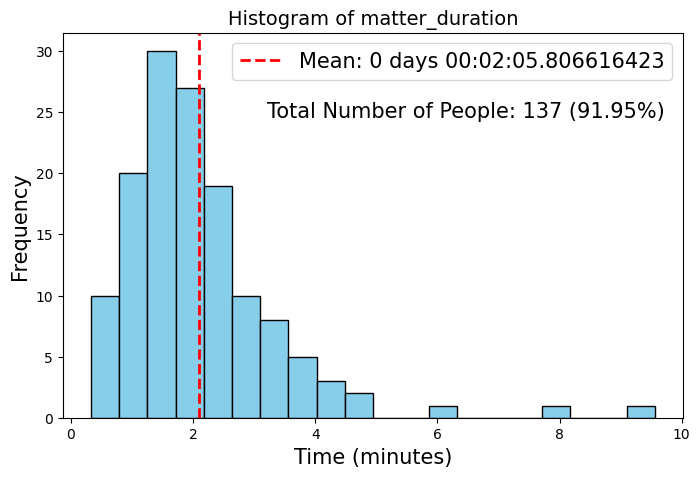

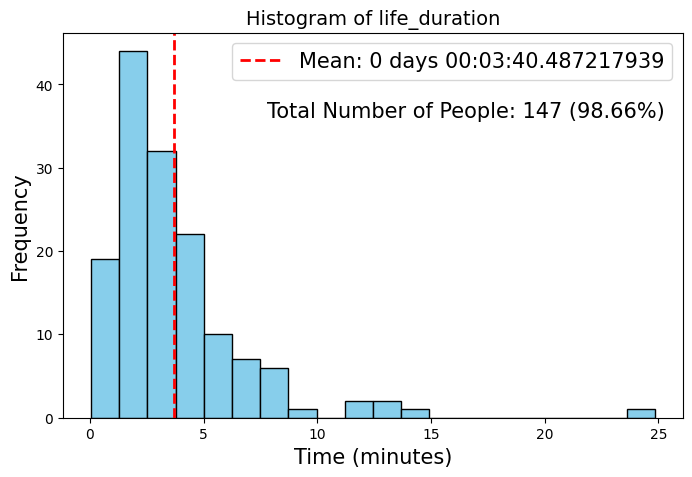

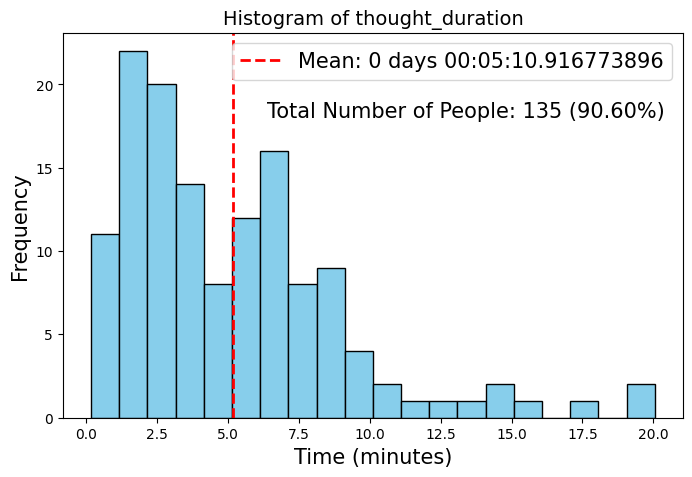

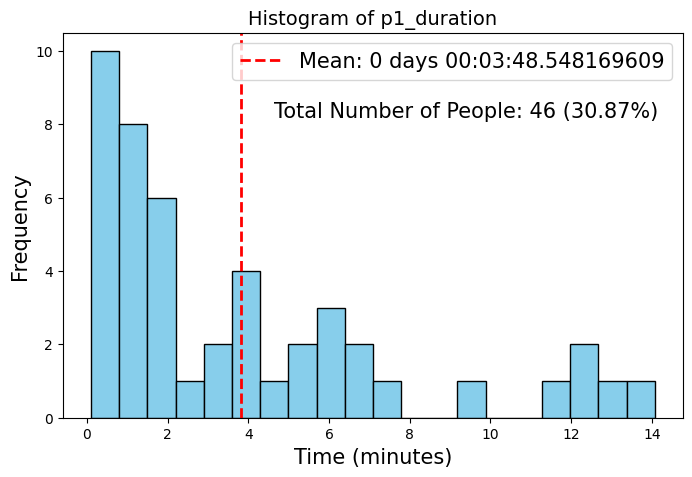

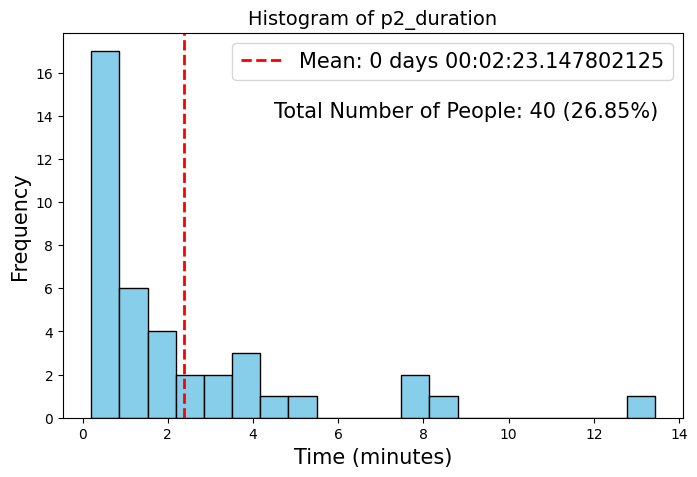

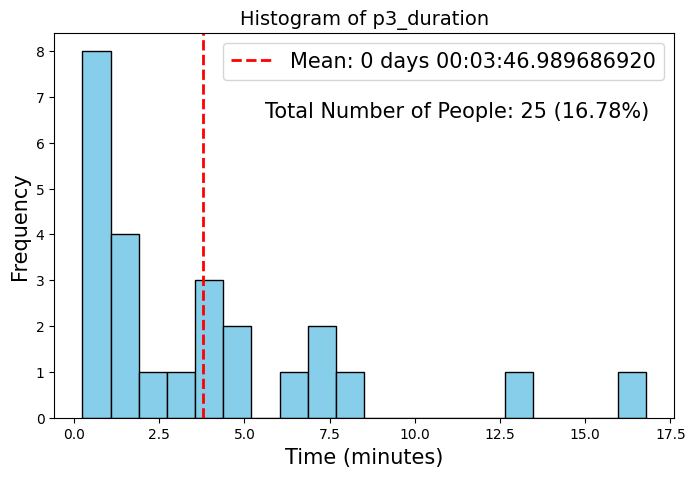

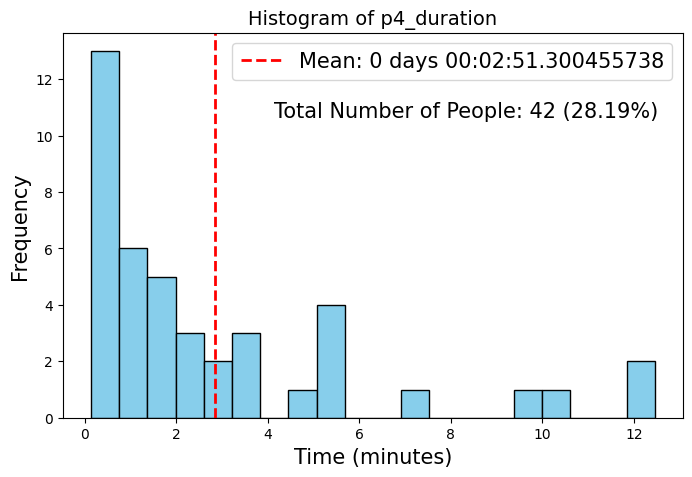

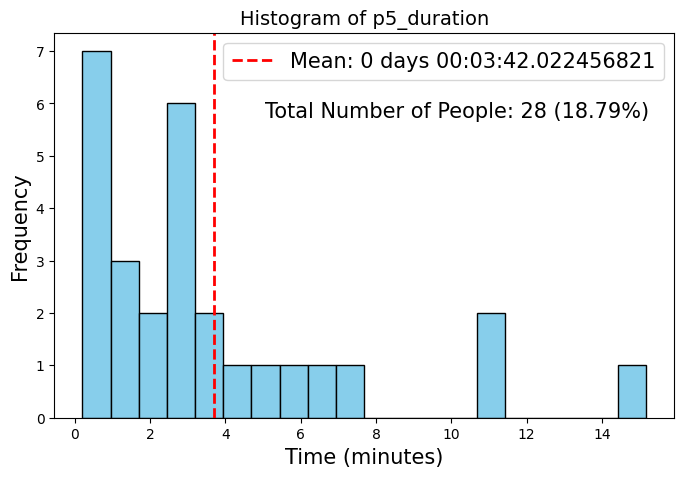

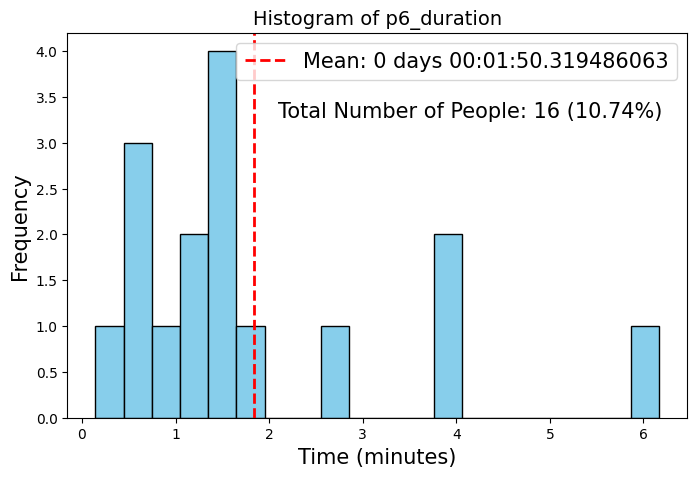

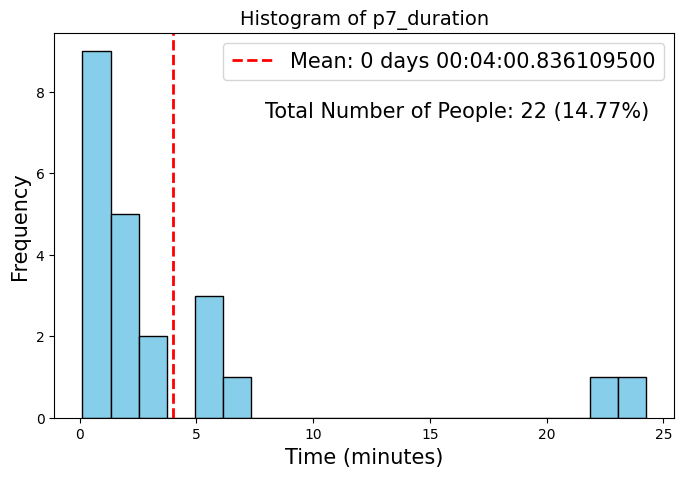

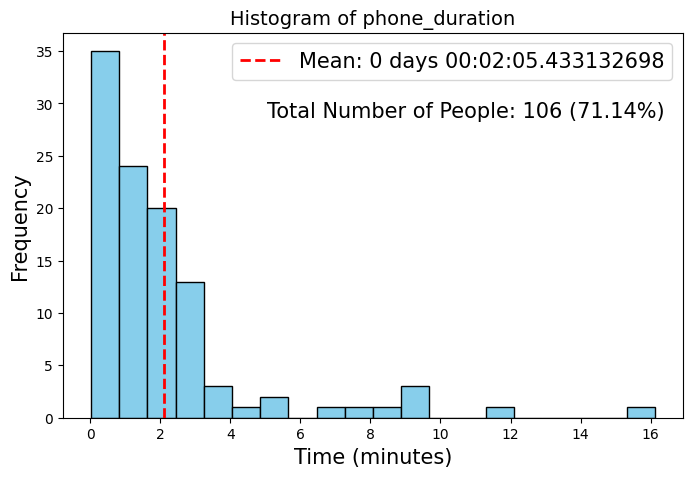

In [149]:
for column in timedelta_columns:
    non_zero_df = filtered_df[filtered_df[column] != pd.Timedelta(0)]
    
    minutes = non_zero_df[column].dt.total_seconds() / 60.0
    
    mean_value_seconds = minutes.mean() * 60
    mean_value_timedelta = pd.to_timedelta(mean_value_seconds, unit='s')
    
    plt.figure(figsize=(8, 5))
    plt.hist(minutes, bins=20, color='skyblue', edgecolor='black')
    
    plt.axvline(mean_value_seconds / 60, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_value_timedelta}')
    
    total_people = len(filtered_df)
    total_people_non_zero = len(non_zero_df)
    percentage_non_zero = (total_people_non_zero / total_people) * 100
    
    annotation_text = f'Total Number of People: {total_people_non_zero} ({percentage_non_zero:.2f}%)'
    plt.annotate(annotation_text, xy=(0.65, 0.78), xycoords='axes fraction', ha='center', fontsize=15)
    
    plt.title(f'Histogram of {column}', fontsize=14)
    plt.xlabel('Time (minutes)', fontsize=15)
    plt.ylabel('Frequency', fontsize=15)
    
    plt.legend(fontsize=15)
    plt.savefig(f'Histogram of {column}.png')
    plt.show()


# What percentage?


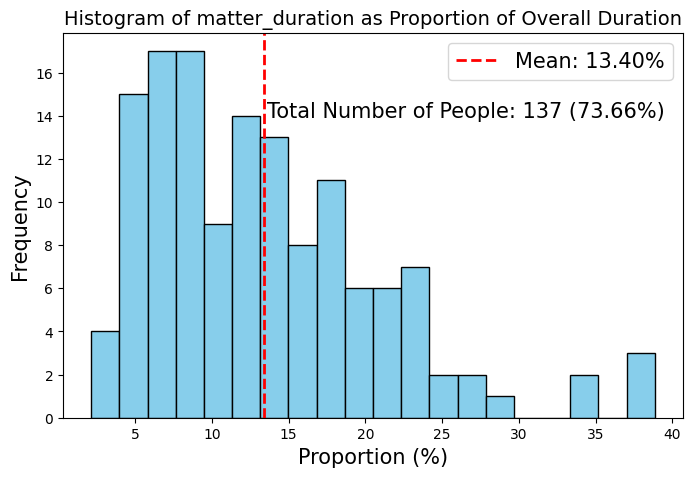

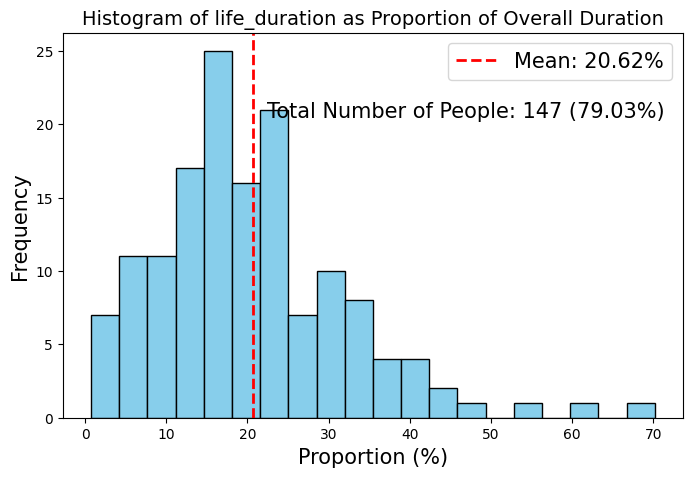

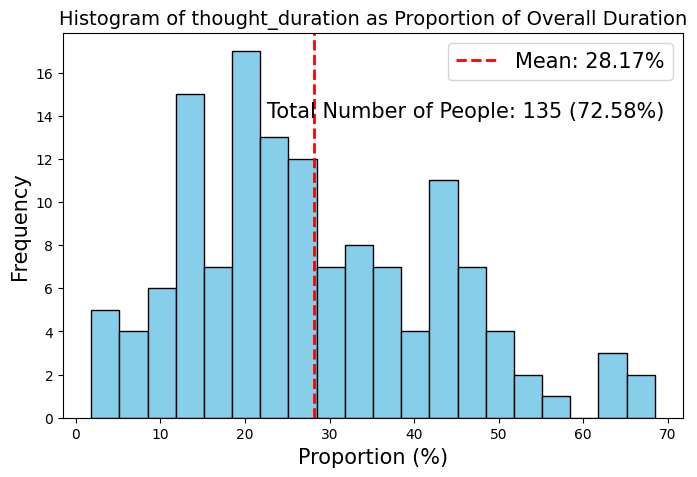

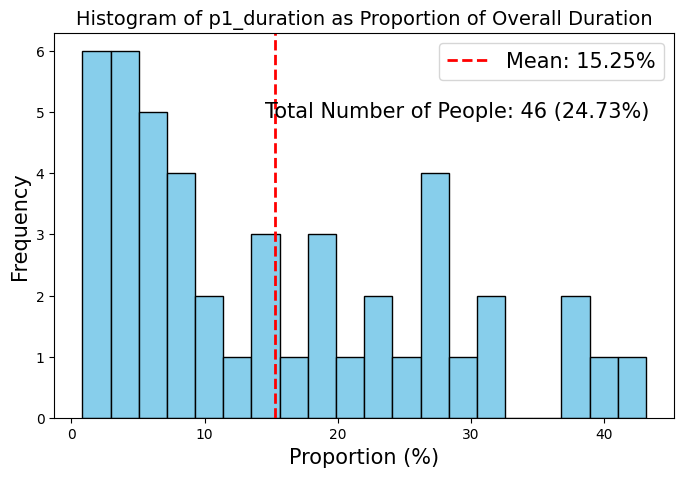

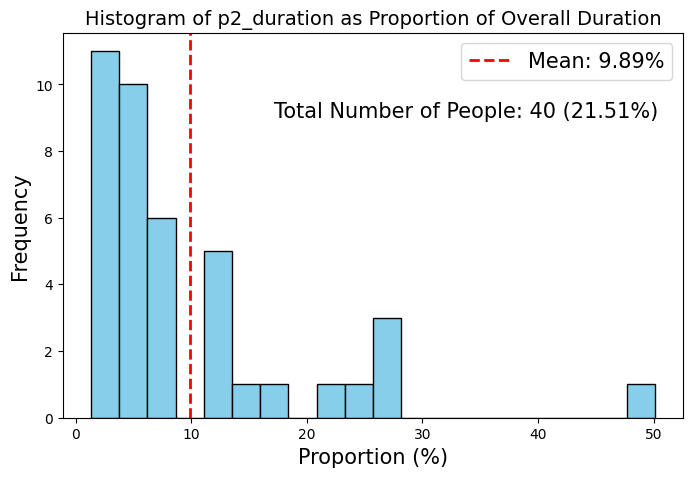

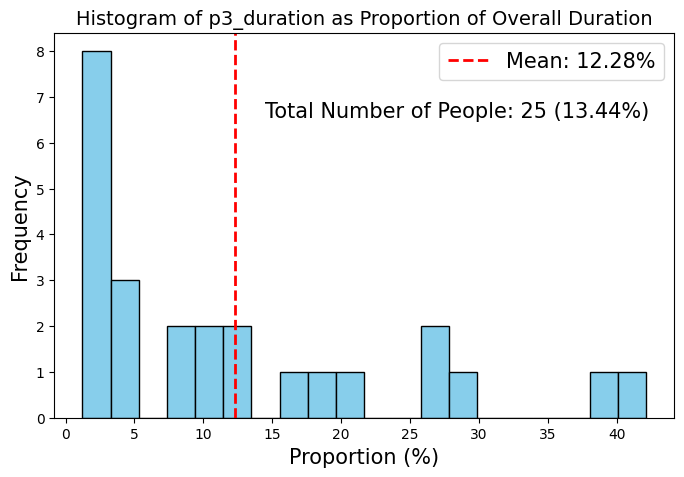

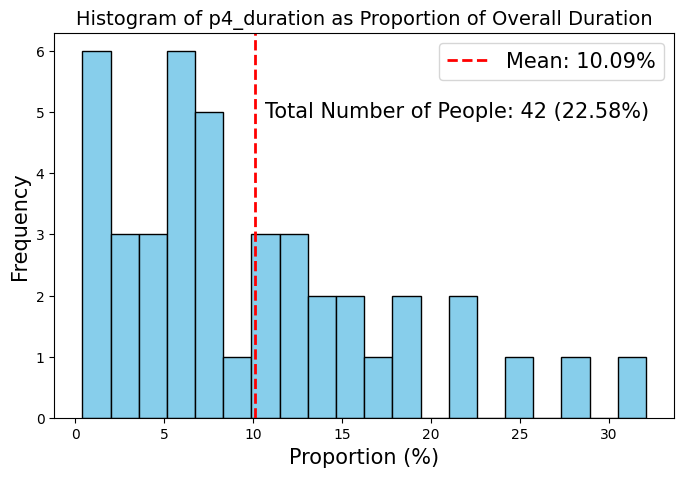

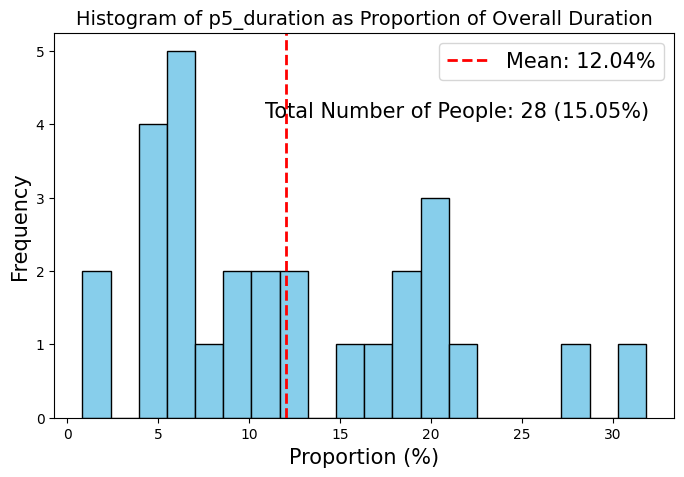

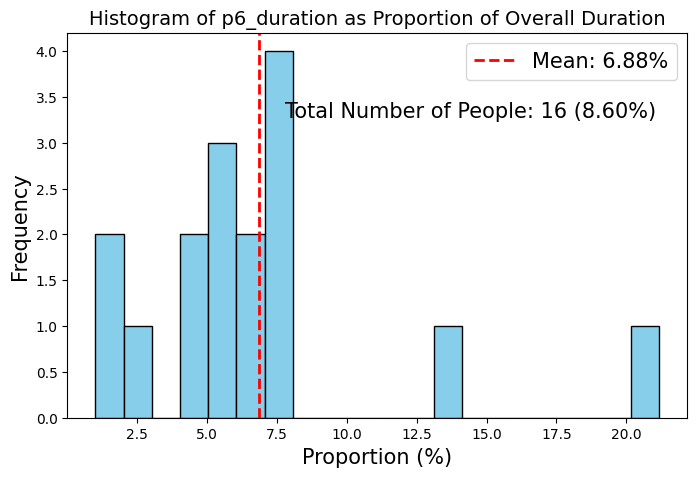

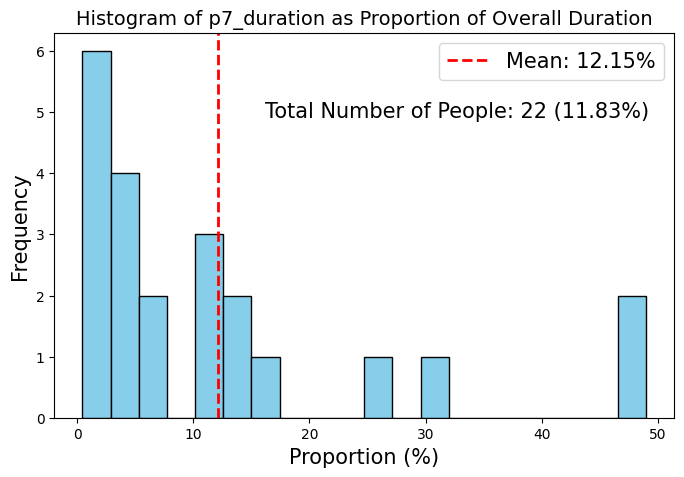

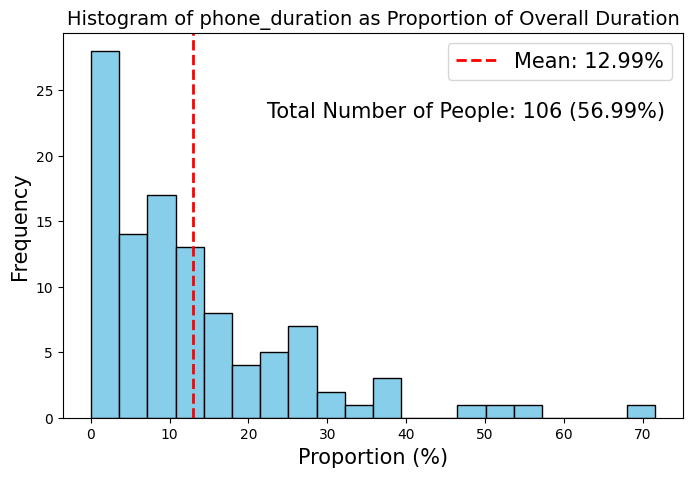

In [150]:
for column in timedelta_columns:
    non_zero_df = filtered_df[filtered_df[column] != pd.Timedelta(0)].copy()
    
    # Calculate durations as a proportion of overall duration
    non_zero_df['proportion'] = (non_zero_df[column] / non_zero_df['overall_duration']) * 100
    
    mean_value_percentage = non_zero_df['proportion'].mean()
    
    plt.figure(figsize=(8, 5))
    plt.hist(non_zero_df['proportion'], bins=20, color='skyblue', edgecolor='black')
    
    plt.axvline(mean_value_percentage, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_value_percentage:.2f}%')
    
    total_people = len(df)
    total_people_non_zero = len(non_zero_df)
    percentage_non_zero = (total_people_non_zero / total_people) * 100
    
    annotation_text = f'Total Number of People: {total_people_non_zero} ({percentage_non_zero:.2f}%)'
    plt.annotate(annotation_text, xy=(0.65, 0.78), xycoords='axes fraction', ha='center', fontsize=15)
    
    plt.title(f'Histogram of {column} as Proportion of Overall Duration', fontsize=14)
    plt.xlabel('Proportion (%)', fontsize=15)
    plt.ylabel('Frequency', fontsize=15)
    
    plt.legend(fontsize=15)
    plt.savefig(f'Histogram of {column}_proportion.png')
    plt.show()


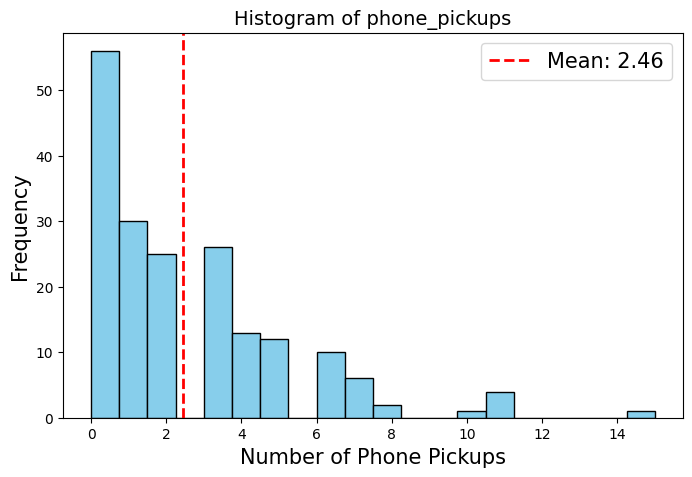

In [151]:
plt.figure(figsize=(8, 5))
plt.hist(df['phone_pickups'], bins=20, color='skyblue', edgecolor='black')

mean_value_phone_pickups = df['phone_pickups'].mean()

plt.axvline(mean_value_phone_pickups, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_value_phone_pickups:.2f}')


plt.title('Histogram of phone_pickups', fontsize=14)
plt.xlabel('Number of Phone Pickups', fontsize=15)
plt.ylabel('Frequency', fontsize=15)

plt.legend(fontsize=15)
plt.savefig('Histogram_of_phone_pickups.png')
plt.show()

In [152]:
df_sorted = df.sort_values(by='overall_duration', ascending=False)[['wearer_name', 'phone_pickups','phone_duration', 'overall_duration', 'matter_duration']]

df_sorted.tail(30)

,wearer_name,phone_pickups,phone_duration,overall_duration,matter_duration
130,D02-P044,4.0,0 days 00:02:15.050845,0 days 00:08:48.185000,0 days 00:01:14.172890
61,D01-P036,0.0,0 days 00:00:00,0 days 00:08:38.221862132,0 days 00:00:00
94,D02-P034,5.0,0 days 00:03:06.741560,0 days 00:08:34.794000,0 days 00:01:21.039091
90,D04-P036,0.0,0 days 00:00:00,0 days 00:08:34.224000,0 days 00:00:44.441066
165,D01-P059,0.0,0 days 00:00:00,0 days 00:08:33.050000,0 days 00:00:00
11,D01-P013,1.0,0 days 00:01:48.432044,0 days 00:08:26.666000,0 days 00:01:42.352500
30,D02-P018,1.0,0 days 00:01:51.950976,0 days 00:08:15.981000,0 days 00:02:18.442452
143,D04-P043,0.0,0 days 00:00:00,0 days 00:08:11.051000,0 days 00:01:04.121267
15,D05-P016,1.0,0 days 00:00:14.390056,0 days 00:07:59.226000,0 days 00:02:39.933752
67,D03-P041,0.0,0 days 00:00:00,0 days 00:07:55.944000,0 days 00:00:26.241840
